In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# cherrypick lol
imdb_path = "dlm_steer_results/42_imdb_manualsearch_csv"
catdog_path = "dlm_steer_results/42_cats_dogs_manualsearch_csv"

imdb_paths_cherry = [
    "dlm_steer_results/42_imdb_manualsearch_csv/from_negative-rs10-st1.0-it0.5.csv",
    "dlm_steer_results/42_imdb_manualsearch_csv/from_positive-rs10-st1.0-it0.5.csv",
]

catdog_paths_cherry = [
    "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_cat-rs10-st1.0-it0.5.csv",
    "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_dog-rs10-st1.0-it0.5.csv",
]

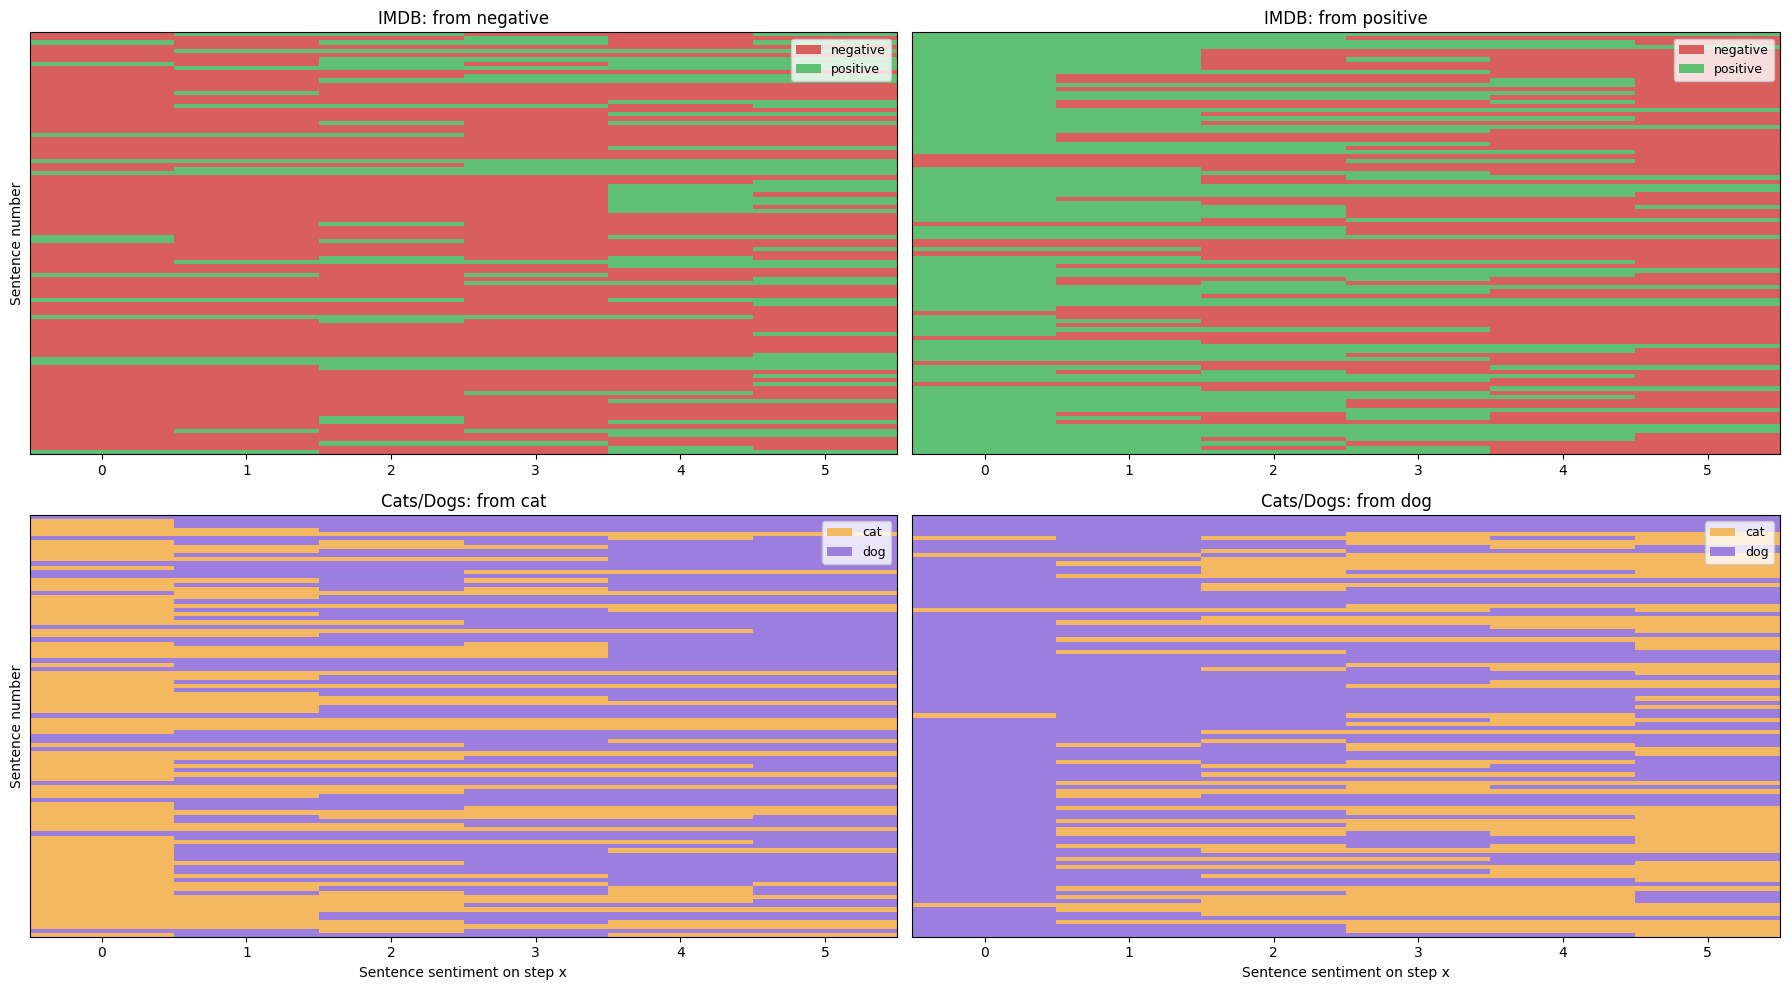

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

all_paths = imdb_paths_cherry + catdog_paths_cherry

all_titles = [
    "IMDB: from negative",
    "IMDB: from positive",
    "Cats/Dogs: from cat",
    "Cats/Dogs: from dog",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, (ax, path, title) in enumerate(zip(axes.ravel(), all_paths, all_titles)):
    df = pd.read_csv(path)

    random_100 = (
        df["instance_number"]
        .drop_duplicates()
        .sample(n=100, random_state=67)
    )

    df = df[df["instance_number"].isin(random_100)].copy()

    df["step"] = df.groupby("instance_number").cumcount()

    grid = df.pivot(
        index="instance_number",
        columns="step",
        values="predicted_label"
    )

    if "imdb" in path:
        label_order = ["negative", "positive"]
        cmap = ListedColormap(["#d95f5f", "#5fbf72"])
    else:
        label_order = ["cat", "dog"]
        cmap = ListedColormap(["#f4b860", "#9b7ede"])

    label_to_num = {label: i for i, label in enumerate(label_order)}
    arr = grid.replace(label_to_num).to_numpy(dtype=float)

    ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    ax.set_title(title)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks([])

    # only bottom row gets x-axis label
    if i in [2, 3]:
        ax.set_xlabel("Sentence sentiment on step x")
    else:
        ax.set_xlabel("")

    # only left column gets y-axis label
    if i in [0, 2]:
        ax.set_ylabel("Sentence number")
    else:
        ax.set_ylabel("")

    handles = [
        Patch(facecolor=cmap.colors[j], label=label_order[j])
        for j in range(len(label_order))
    ]

    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
        fontsize=9
    )
fig.tight_layout()
plt.show()